## 1. Environment Setup

In [1]:
import sys
import subprocess
import importlib.util


def install_if_missing(import_name, pip_name=None):
    """Install a package only when it is not available."""
    if pip_name is None:
        pip_name = import_name

    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
    else:
        print(f"{pip_name} already installed")


install_if_missing("numpy")
install_if_missing("torch")
install_if_missing("websockets")
install_if_missing('pandas')
install_if_missing('matplotlib')

numpy already installed
torch already installed
websockets already installed
pandas already installed
matplotlib already installed


## 2. Import Libraries

In [2]:
import asyncio
import json
import os
import random
from collections import deque
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

## 3. WebSocket Server Import

In [3]:
try:
    from websockets.asyncio.server import serve
except ImportError:
    import websockets
    serve = websockets.serve

## 4. Reproducibility

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


## 5. SARSA Configuration

In [5]:
# Number of values used to represent the environment state.
# Current Godot state:
# apples_collected
# apple_direction_x
# apple_direction_y
# vertical_state
# grounded
# snail_danger
STATE_SIZE = 6


# Number of possible actions.
# 0 = Idle
# 1 = Move Left
# 2 = Move Right
# 3 = Jump
ACTION_SIZE = 6


# Q-table file used to save and load the learned policy.
Q_TABLE_PATH = "sarsa_q_table.json"


# Training log file
LOG_PATH = "sarsa_training_log.csv"


# TCP server configuration used to communicate with Godot.
HOST = "127.0.0.1"
PORT = 9999


# Training settings
TRAINING_MODE = True

EPISODES = 1000


# SARSA hyperparameters

# Learning rate
ALPHA = 0.1

# Discount factor
GAMMA = 0.9

# Initial exploration rate
EPSILON = 1.0

# Minimum exploration rate
MIN_EPSILON = 0.05

# Exploration decay after each episode
EPSILON_DECAY = 0.995


# Console output frequency
PRINT_EVERY_N_EPISODES = 10


# Reproducibility
SEED = 42


print("================================")
print("SARSA CONFIGURATION")
print("================================")

print("State size:", STATE_SIZE)
print("Action size:", ACTION_SIZE)

print("Learning rate (Alpha):", ALPHA)
print("Discount factor (Gamma):", GAMMA)
print("Initial Epsilon:", EPSILON)

print("Training mode:", TRAINING_MODE)

print("Host:", HOST)
print("Port:", PORT)

print("Random seed:", SEED)

SARSA CONFIGURATION
State size: 6
Action size: 6
Learning rate (Alpha): 0.1
Discount factor (Gamma): 0.9
Initial Epsilon: 1.0
Training mode: True
Host: 127.0.0.1
Port: 9999
Random seed: 42


## 6. Action Space

In [6]:
ACTION_NAMES = {
    0: "idle",
    1: "left",
    2: "right",
    3: "jump",
    4: "left+jump",
    5: "right+jump",
}

# During random exploration, these actions are sampled more often.
# This prevents the agent from wasting too much time moving left in a right-moving platformer.
EXPLORATION_ACTIONS = [0, 1, 2, 3, 4, 5]

for action_id, action_name in ACTION_NAMES.items():
    print(action_id, "=", action_name)

0 = idle
1 = left
2 = right
3 = jump
4 = left+jump
5 = right+jump


## 7. State Representation

In [7]:
state_description = {
    0: "state value 0 from Godot",
    1: "state value 1 from Godot",
    2: "state value 2 from Godot",
    3: "state value 3 from Godot",
    4: "state value 4 from Godot",
    5: "state value 5 from Godot",
    6: "state value 6 from Godot",
    7: "wall_low / lower wall sensor",
    8: "wall_high / upper wall sensor",
    9: "floor_ahead sensor",
    10: "on_floor status",
    11: "additional game state value",
    12: "collected_ratio / apple collection progress",
}

for index, meaning in state_description.items():
    print(f"state[{index}] = {meaning}")

state[0] = state value 0 from Godot
state[1] = state value 1 from Godot
state[2] = state value 2 from Godot
state[3] = state value 3 from Godot
state[4] = state value 4 from Godot
state[5] = state value 5 from Godot
state[6] = state value 6 from Godot
state[7] = wall_low / lower wall sensor
state[8] = wall_high / upper wall sensor
state[9] = floor_ahead sensor
state[10] = on_floor status
state[11] = additional game state value
state[12] = collected_ratio / apple collection progress


## 8. SARSA Agent

In [8]:
class SARSAAgent:

    def __init__(
        self,
        actions,
        alpha=ALPHA,
        gamma=GAMMA,
        epsilon=EPSILON
    ):
        self.actions = actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = {}

    def get_q_values(self, state):

        if state not in self.q_table:
            self.q_table[state] = {
                action: 0.0
                for action in self.actions
            }

        return self.q_table[state]

    def get_action(self, state):

        q_values = self.get_q_values(state)

        if random.random() < self.epsilon:
            return random.choice(EXPLORATION_ACTIONS)

        max_q = max(q_values.values())

        best_actions = [
            action
            for action, q_value in q_values.items()
            if q_value == max_q
        ]

        return random.choice(best_actions)

    def update(
        self,
        state,
        action,
        reward,
        next_state,
        next_action
    ):

        q_values = self.get_q_values(state)
        next_q_values = self.get_q_values(next_state)

        current_q = q_values[action]
        next_q = next_q_values[next_action]

        target = reward + self.gamma * next_q

        q_values[action] = (
            current_q
            + self.alpha * (target - current_q)
        )

    def decay_epsilon(self):

        self.epsilon = max(
            MIN_EPSILON,
            self.epsilon * EPSILON_DECAY
        )

    # ========================================================
    # SAVE Q-TABLE
    # ========================================================

    def save_q_table(self, filename=Q_TABLE_PATH):

        table_to_save = {}

        for state, actions in self.q_table.items():

            table_to_save[state] = {
                str(action): q_value
                for action, q_value in actions.items()
            }

        with open(filename, "w") as file:

            json.dump(
                table_to_save,
                file,
                indent=4
            )

        print()
        print("Q-table saved successfully.")
        print("File:", filename)
        print("Number of states:", len(self.q_table))

    # ========================================================
    # LOAD Q-TABLE
    # ========================================================

    def load_q_table(self, filename=Q_TABLE_PATH):

        if not os.path.exists(filename):

            print()
            print("Q-table file not found.")
            print("Starting with an empty Q-table.")

            return False

        with open(filename, "r") as file:

            loaded_table = json.load(file)

        self.q_table = {}

        for state, actions in loaded_table.items():

            self.q_table[state] = {
                int(action): float(q_value)
                for action, q_value in actions.items()
            }

        print()
        print("Q-table loaded successfully.")
        print("File:", filename)
        print("Number of states:", len(self.q_table))

        return True

## 9. Q-table Save

In [9]:
    def save_q_table(self, filename=Q_TABLE_PATH):

        # Convert action keys from int to string
        # because JSON requires dictionary keys to be strings.
        table_to_save = {}

        for state, actions in self.q_table.items():

            table_to_save[state] = {
                str(action): q_value
                for action, q_value in actions.items()
            }

        with open(filename, "w") as file:

            json.dump(
                table_to_save,
                file,
                indent=4
            )

        print()
        print("Q-table saved successfully.")
        print("File:", filename)
        print("Number of states:", len(self.q_table))

    def load_q_table(self, filename=Q_TABLE_PATH):

        if not os.path.exists(filename):

            print()
            print("Q-table file not found.")
            print("Starting with an empty Q-table.")

            return False


        with open(filename, "r") as file:

            loaded_table = json.load(file)


        self.q_table = {}

        for state, actions in loaded_table.items():

            self.q_table[state] = {
                int(action): float(q_value)
                for action, q_value in actions.items()
            }


        print()
        print("Q-table loaded successfully.")
        print("File:", filename)
        print("Number of states:", len(self.q_table))

        return True

## 10. Godot <-> Python TCP Communication

In [10]:
import socket
# TCP Communication

def clean_message(message):
    message = message.replace("\x00", "")
    message = message.strip()

    return message


def send_action(conn, action):
    """
    Send an action from Python to Godot.
    """

    packet = {
        "action": int(action)
    }

    message = json.dumps(packet) + "\n"

    conn.sendall(
        message.encode("utf-8")
    )

    print(
        "Sent action:",
        action,
        ACTION_NAMES.get(action, "unknown")
    )


def parse_message(raw_message):
    """
    Convert a JSON message received from Godot
    into a Python dictionary.
    """

    raw_message = clean_message(raw_message)

    if not raw_message:
        return None

    try:

        message = json.loads(raw_message)

        return message

    except json.JSONDecodeError as error:

        print()
        print("Invalid JSON received.")
        print("Raw message:", repr(raw_message))
        print("Error:", error)

        return None


# TCP Server

def start_tcp_server():

    print()
    print("================================")
    print("SARSA TCP SERVER")
    print("================================")

    server_socket = socket.socket(
        socket.AF_INET,
        socket.SOCK_STREAM
    )

    server_socket.setsockopt(
        socket.SOL_SOCKET,
        socket.SO_REUSEADDR,
        1
    )

    server_socket.bind(
        (HOST, PORT)
    )

    server_socket.listen(1)

    print(
        f"Waiting for Godot on "
        f"{HOST}:{PORT}..."
    )

    conn, address = server_socket.accept()

    print()
    print("Godot connected!")
    print("Address:", address)

    return server_socket, conn

## 11. Message Handling and SARSA <-> GODOT Connection

In [11]:
# 11.1: Message Handling
def clean_message(message):
    message = message.replace("\x00", "")
    message = message.strip()
    return message


def send_action(conn, action):

    packet = {
        "action": int(action)
    }

    message = json.dumps(packet) + "\n"

    conn.sendall(
        message.encode("utf-8")
    )

    print(
        "Sent action:",
        action,
        ACTION_NAMES.get(action, "unknown")
    )


def parse_message(raw_message):

    raw_message = clean_message(raw_message)

    if not raw_message:
        return None

    try:
        return json.loads(raw_message)

    except json.JSONDecodeError as error:

        print()
        print("Invalid JSON received.")
        print("Raw message:", repr(raw_message))
        print("Error:", error)

        return None

In [12]:
# 11.2: SARSA ↔ Godot Connection

def run_sarsa_connection(agent):

    # ========================================================
    # Training history
    # ========================================================

    training_rewards = []
    training_steps = []
    training_epsilons = []


    # ========================================================
    # Start TCP server
    # ========================================================

    server_socket, conn = start_tcp_server()


    # ========================================================
    # SARSA episode variables
    # ========================================================

    current_state = None
    current_action = None

    episode = 0
    episode_reward = 0.0
    episode_steps = 0


    # ========================================================
    # TCP buffer
    # ========================================================

    buffer = ""


    try:

        # ====================================================
        # Main training loop
        # ====================================================

        while episode < EPISODES:

            # ------------------------------------------------
            # Receive data from Godot
            # ------------------------------------------------

            raw_data = conn.recv(4096)

            if not raw_data:

                print()
                print("================================")
                print("GODOT DISCONNECTED")
                print("================================")
                print("The TCP connection was closed by Godot.")

                break


            decoded_data = raw_data.decode(
                "utf-8",
                errors="replace"
            )


            # ------------------------------------------------
            # Remove null bytes
            # ------------------------------------------------

            decoded_data = decoded_data.replace(
                "\x00",
                ""
            )


            # ------------------------------------------------
            # Add received data to buffer
            # ------------------------------------------------

            buffer += decoded_data


            # =================================================
            # Process complete messages
            # =================================================

            while "\n" in buffer:

                raw_message, buffer = buffer.split(
                    "\n",
                    1
                )


                message = parse_message(
                    raw_message
                )


                if message is None:
                    continue


                message_type = message.get(
                    "type"
                )


                # =============================================
                # RESET MESSAGE
                # =============================================

                if message_type == "reset":

                    episode += 1


                    current_state = str(
                        message.get("state")
                    )


                    episode_reward = 0.0
                    episode_steps = 0


                    # -----------------------------------------
                    # Choose first action
                    # -----------------------------------------

                    current_action = agent.get_action(
                        current_state
                    )


                    print()
                    print(
                        "================================"
                    )
                    print(
                        f"Episode {episode}/{EPISODES}"
                    )
                    print(
                        "Initial state:",
                        current_state
                    )
                    print(
                        "Initial action:",
                        current_action,
                        ACTION_NAMES[current_action]
                    )


                    # -----------------------------------------
                    # Send first action to Godot
                    # -----------------------------------------

                    send_action(
                        conn,
                        current_action
                    )


                # =============================================
                # STEP MESSAGE
                # =============================================

                elif message_type == "step":

                    next_state = str(
                        message.get("state")
                    )


                    reward = float(
                        message.get(
                            "reward",
                            0.0
                        )
                    )


                    done = bool(
                        message.get(
                            "done",
                            False
                        )
                    )


                    # -----------------------------------------
                    # Record episode information
                    # -----------------------------------------

                    episode_reward += reward
                    episode_steps += 1


                    print(
                        "State:",
                        next_state,
                        "| Reward:",
                        reward,
                        "| Done:",
                        done
                    )


                    # -----------------------------------------
                    # Select next action
                    #
                    # SARSA:
                    #
                    # S -> A -> R -> S' -> A'
                    #
                    # The next action A' is selected BEFORE
                    # updating Q(S,A).
                    # -----------------------------------------

                    next_action = agent.get_action(
                        next_state
                    )


                    # -----------------------------------------
                    # SARSA Q-value update
                    # -----------------------------------------

                    if (
                        current_state is not None
                        and current_action is not None
                    ):

                        if not done:

                            agent.update(
                                current_state,
                                current_action,
                                reward,
                                next_state,
                                next_action
                            )


                    # =========================================
                    # Episode finished
                    # =========================================

                    if done:

                        print(
                            f"Episode {episode} "
                            f"finished | "
                            f"Total reward: "
                            f"{episode_reward:.2f} "
                            f"Steps: {episode_steps}"
                        )


                        # -------------------------------------
                        # Store training information
                        # -------------------------------------

                        training_rewards.append(
                            episode_reward
                        )

                        training_steps.append(
                            episode_steps
                        )


                        # -------------------------------------
                        # Decay epsilon
                        # -------------------------------------

                        agent.decay_epsilon()


                        training_epsilons.append(
                            agent.epsilon
                        )


                        print(
                            "Epsilon:",
                            round(
                                agent.epsilon,
                                4
                            )
                        )


                        # -------------------------------------
                        # Save Q-table every N episodes
                        # -------------------------------------

                        if (
                            TRAINING_MODE
                            and
                            episode % PRINT_EVERY_N_EPISODES == 0
                        ):

                            agent.save_q_table(
                                Q_TABLE_PATH
                            )


                        # -------------------------------------
                        # Clear current transition
                        # -------------------------------------

                        current_state = None
                        current_action = None


                        # -------------------------------------
                        # Tell Godot to reset
                        #
                        # Keep your existing -1 behaviour.
                        # -------------------------------------

                        send_action(
                            conn,
                            -1
                        )


                    else:

                        # -------------------------------------
                        # Move to next SARSA transition
                        # -------------------------------------

                        current_state = next_state

                        current_action = next_action


                        # -------------------------------------
                        # Send A' to Godot
                        # -------------------------------------

                        send_action(
                            conn,
                            current_action
                        )


    # ========================================================
    # Connection error handling
    # ========================================================

    except ConnectionResetError:

        print(
            "Godot connection reset."
        )


    # ========================================================
    # Cleanup
    # ========================================================

    finally:

        # ----------------------------------------------------
        # Save final Q-table
        # ----------------------------------------------------

        if TRAINING_MODE:

            agent.save_q_table(
                Q_TABLE_PATH
            )


        # ----------------------------------------------------
        # Close connection
        # ----------------------------------------------------

        conn.close()
        server_socket.close()


        print()


        # ====================================================
        # Save training log
        # ====================================================

        if len(training_rewards) > 0:

            log_data = pd.DataFrame({

                "episode":
                    range(
                        1,
                        len(training_rewards) + 1
                    ),

                "reward":
                    training_rewards,

                "steps":
                    training_steps,

                "epsilon":
                    training_epsilons
            })


            log_data.to_csv(
                LOG_PATH,
                index=False
            )


            print()
            print(
                "Training log saved successfully."
            )

            print(
                "File:",
                LOG_PATH
            )

            print(
                "Episodes logged:",
                len(training_rewards)
            )

        else:

            print()
            print(
                "No training data was recorded."
            )


        print(
            "SARSA server closed."
        )

In [13]:
# 11.3: Launch SARSA

actions = list(ACTION_NAMES.keys())

agent = SARSAAgent(
    actions=actions
)

if not TRAINING_MODE:

    agent.epsilon = 0.0

    agent.load_q_table(
        Q_TABLE_PATH
    )


run_sarsa_connection(
    agent
)


SARSA TCP SERVER
Waiting for Godot on 127.0.0.1:9999...

Godot connected!
Address: ('127.0.0.1', 53574)

Episode 1/1000
Initial state: 0_0_0_0_1_1
Initial action: 0 idle
Sent action: 0 idle
State: 0_0_0_0_1_1 | Reward: -0.05 | Done: False
Sent action: 1 left
State: 0_0_0_0_1_1 | Reward: -0.05 | Done: False
Sent action: 5 right+jump
State: 0_0_0_1_0_1 | Reward: -0.05 | Done: False
Sent action: 5 right+jump
State: 0_0_0_1_0_1 | Reward: -0.05 | Done: False
Sent action: 0 idle
State: 0_0_0_1_0_1 | Reward: -0.05 | Done: False
Sent action: 0 idle
State: 0_0_0_-1_0_1 | Reward: -0.05 | Done: False
Sent action: 1 left
State: 0_0_0_-1_0_1 | Reward: -0.05 | Done: False
Sent action: 4 left+jump
State: 0_0_0_-1_0_1 | Reward: -0.05 | Done: False
Sent action: 1 left
State: 0_0_0_-1_0_1 | Reward: -0.05 | Done: False
Sent action: 5 right+jump
State: 0_0_0_-1_0_1 | Reward: -0.05 | Done: False
Sent action: 1 left
State: 0_0_0_-1_0_1 | Reward: -0.05 | Done: False
Sent action: 2 right
State: 0_0_0_-1_0_1 

## 12. Record Training Result

In [12]:
# Display Q-table

import json
import pandas as pd

Q_TABLE_PATH = "sarsa_q_table.json"

# Load Q-table
with open(Q_TABLE_PATH, "r") as file:
    q_table_data = json.load(file)

# Convert Q-table into a DataFrame
q_table_df = pd.DataFrame.from_dict(
    q_table_data,
    orient="index"
)

q_table_df.index.name = "State"

display(q_table_df)

print("Number of states:", len(q_table_df))

,0,1,2,3,4,5
State,,,,,,
0_0_0_0_1_1,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999
0_0_0_1_0_1,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999
0_0_0_-1_0_1,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999
0_0_0_0_0_1,-0.499998,-0.499999,-0.499998,-0.499998,-0.499999,-0.499999
0_0_0_0_1_0,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999
0_0_0_-1_0_0,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999
0_0_0_1_0_0,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999
0_0_0_0_0_0,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999,-0.499999
1_0_0_0_1_0,-0.023558,-0.024612,-0.035441,-0.031723,-0.026480,-0.025964


Number of states: 16


In [8]:
# Display .csv File

import pandas as pd
LOG_PATH = "sarsa_training_log.csv"
training_data = pd.read_csv(LOG_PATH)

display(training_data)
display("Number of recorded episodes:", len(training_data))

,episode,reward,steps,epsilon
0,1,-200.65,13,0.995000
1,2,-203.30,66,0.990025
2,3,-203.20,64,0.985075
3,4,-206.85,137,0.980150
4,5,-204.40,88,0.975249
...,...,...,...,...
994,995,-203.30,66,0.050000
995,996,-202.00,40,0.050000
996,997,-205.40,108,0.050000
997,998,-201.05,21,0.050000


'Number of recorded episodes:'

999

## 13. Training Performance Visualization

In [20]:
import matplotlib.pyplot as plt

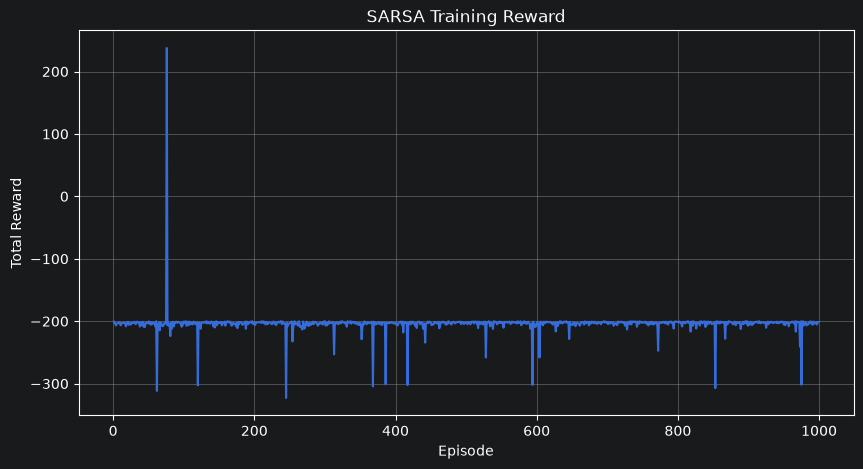

In [21]:
# Total Reward per Episode
plt.figure(figsize=(10, 5))

plt.plot(
    training_data["episode"],
    training_data["reward"]
)

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SARSA Training Reward")

plt.grid(True)
plt.show()

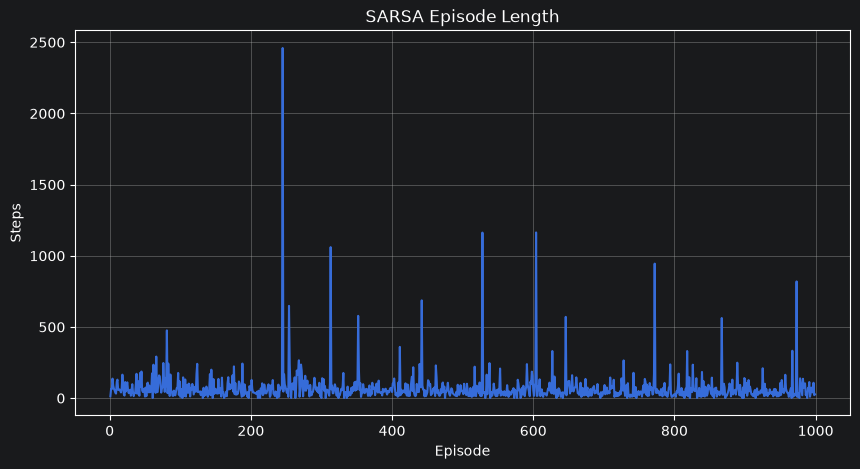

In [22]:
# Total Steps per Episode

plt.figure(figsize=(10, 5))

plt.plot(
    training_data["episode"],
    training_data["steps"]
)

plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("SARSA Episode Length")

plt.grid(True)
plt.show()

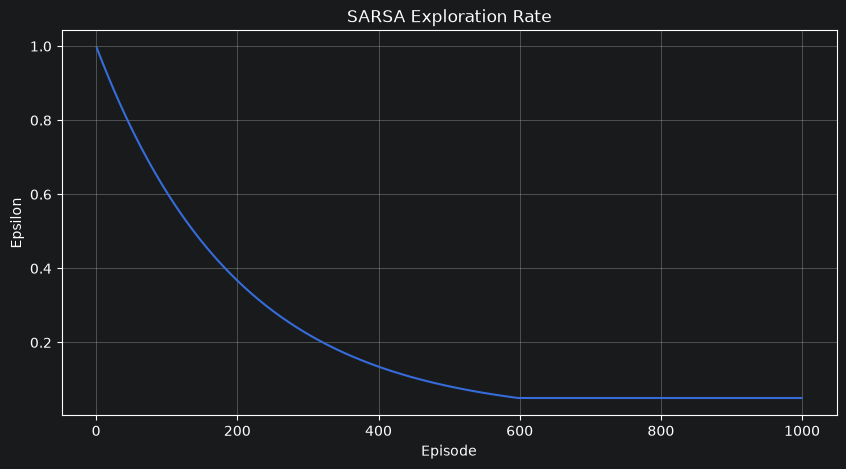

In [23]:
# Epsilon Decay

plt.figure(figsize=(10, 5))

plt.plot(
    training_data["episode"],
    training_data["epsilon"]
)

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("SARSA Exploration Rate")

plt.grid(True)
plt.show()

## End